# Visualizing Machine Learning Models

You asked how Logistic Regression (66.38%) and Random Forest (68.57%) actually make decisions differently. 

To visualize this, we are going to do something special: we are going to train both models using **only two features** (`age_diff` and `sig_str_diff`). Because we only have two features, we can map them to the X and Y axis of a 2D graph!

We will plot all the fights on the graph:
*   **Red Dots:** Red fighter won.
*   **Blue Dots:** Blue fighter won.

Then, we will color the background to show what the model *predicts* will happen in that area of the graph. This is called a **Decision Boundary**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay

# Make it look pretty
plt.style.use('dark_background')
sns.set_palette("husl")

# 1. Load data
df = pd.read_csv('../data/processed/ufc-ml-features.csv')

# 2. Select just TWO features so we can visualize it in 2D
# We will use Age Difference and Significant Strike Difference
X = df[['age_diff', 'sig_str_diff']].fillna(0)
y = df['Winner']

# 3. Train BOTH models on just these two features
lr_model = LogisticRegression()
lr_model.fit(X, y)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X, y)

print("Models Trained! Let's plot them.")

Models Trained! Let's plot them.


## The Decision Boundaries: Linear vs. Non-Linear

Look closely at the two graphs below. 

1.  **Logistic Regression (Left):** Notice how it draws a single, perfectly straight line across the entire graph. It says "If you are above this exact mathematical line, you win. If below, you lose." It is very rigid.
2.  **Random Forest (Right):** Notice how blocky and complex the background is! Because it uses Decision Trees (flowcharts), it can carve out specific little "islands" and rules. It can say, "If you have a massive strike advantage, you win, UNLESS you are 15 years older, then you lose." It is non-linear.

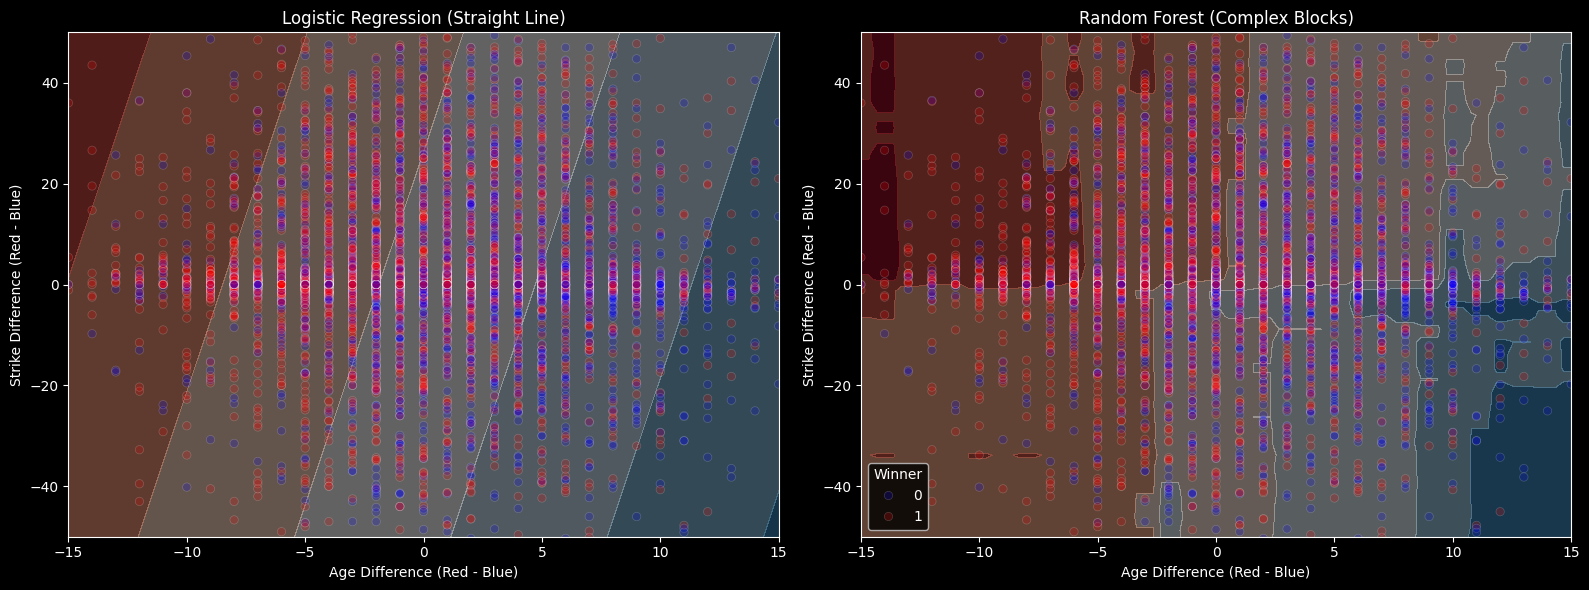

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Custom color map for Red vs Blue
cmap = plt.cm.RdBu_r

# --- Plot 1: Logistic Regression ---
DecisionBoundaryDisplay.from_estimator(
    lr_model, X, cmap=cmap, alpha=0.4, ax=ax1, eps=0.5
)
sns.scatterplot(
    data=df, x='age_diff', y='sig_str_diff', hue='Winner', 
    palette={1: 'red', 0: 'blue'}, alpha=0.2, ax=ax1, legend=False
)
ax1.set_title("Logistic Regression (Straight Line)")
ax1.set_xlim(-15, 15)
ax1.set_ylim(-50, 50)
ax1.set_xlabel("Age Difference (Red - Blue)")
ax1.set_ylabel("Strike Difference (Red - Blue)")

# --- Plot 2: Random Forest ---
DecisionBoundaryDisplay.from_estimator(
    rf_model, X, cmap=cmap, alpha=0.4, ax=ax2, eps=0.5
)
sns.scatterplot(
    data=df, x='age_diff', y='sig_str_diff', hue='Winner', 
    palette={1: 'red', 0: 'blue'}, alpha=0.2, ax=ax2, legend=True
)
ax2.set_title("Random Forest (Complex Blocks)")
ax2.set_xlim(-15, 15)
ax2.set_ylim(-50, 50)
ax2.set_xlabel("Age Difference (Red - Blue)")
ax2.set_ylabel("Strike Difference (Red - Blue)")

plt.tight_layout()
plt.show()